# RetailRocket: experiment report

Purchase-target Hawkes (multi-type history) vs **scaled seasonal baseline**.

Baseline seasonality is **global hour-of-week (168 bins)** fitted on pooled *train* purchases across users; then each user gets its own `mu` via MLE scaling.


In [13]:
%matplotlib inline
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'src').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

RESULTS_ROOT = ROOT / 'results/retailrocket'
print('ROOT:', ROOT)
print('RESULTS_ROOT:', RESULTS_ROOT)


ROOT: /Users/amosh239/repo/mkn/Hawk's proccess
RESULTS_ROOT: /Users/amosh239/repo/mkn/Hawk's proccess/results/retailrocket


In [14]:
import pandas as pd
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt

# Choose a run (defaults to the latest retailrocket-YYYYMMDD-HHMMSS folder).
RUN_ID = None # set to None to auto-pick latest
runs = sorted(RESULTS_ROOT.glob('retailrocket-*'))
if not runs:
    raise FileNotFoundError('No runs found. Run: .venv/bin/python scripts/run_real.py --dataset retailrocket')
RUN_DIR = (RESULTS_ROOT / RUN_ID) if RUN_ID else runs[-1]
SUMMARY_PATH = RUN_DIR / 'summary.csv'

df = pd.read_csv(SUMMARY_PATH)
print('RUN_DIR:', RUN_DIR)
print('rows:', len(df))
df.head(5)


RUN_DIR: /Users/amosh239/repo/mkn/Hawk's proccess/results/retailrocket/retailrocket-20260127-142831
rows: 92


,seq_id,n_events,train_events,test_events,purchases_train,purchases_test,test_hours,ll_unit,ll_baseline,ll_hawkes,ll_gain,mu_baseline,mu_hawkes,mu,alpha_type_0,alpha_type_1,alpha_type_2
0,38015,861,651,210,2,0,307.903921,per_hour,-0.001523,-0.000001,0.001522,0.001249,0.000001,0.000001,0.000000,5.0,0.000000
1,53842,862,795,67,61,3,98.382626,per_hour,-0.219198,0.017983,0.237181,0.141127,0.000001,0.000001,0.030900,5.0,0.000000
2,57905,732,581,151,27,17,72.498278,per_hour,-0.443981,0.184162,0.628143,0.073240,0.000001,0.000001,0.000000,5.0,0.000000
3,76757,1883,1326,557,114,71,287.491879,per_hour,-0.404172,0.134757,0.538928,0.097679,0.000001,0.000001,0.015832,5.0,0.641907
4,85734,1461,985,476,12,3,936.124127,per_hour,-0.021718,-0.013589,0.008129,0.008284,0.000001,0.000001,0.000000,5.0,0.000000


## Metrics
Notes:
- `ll_unit=per_hour`: test log-likelihood is normalized per hour of the test window.
- `ll_gain = ll_hawkes - ll_baseline`: **positive means Hawkes is better**.


In [15]:
wins = (df.ll_gain > 0)
p0 = (df.purchases_test == 0)

def pct(x):
    return 100.0 * float(x)

print('win rate (overall):', f'{pct(wins.mean()):.1f}%')
print('win rate (purchases_test==0):', f'{pct(wins[p0].mean()):.1f}%' if p0.any() else 'n/a')
print('win rate (purchases_test>0):', f'{pct(wins[~p0].mean()):.1f}%' if (~p0).any() else 'n/a')

print('purchases_test==0 share:', f'{pct(p0.mean()):.1f}%')
print('median ll_gain:', float(df.ll_gain.median()))
print('mean ll_gain:', float(df.ll_gain.mean()))
print('median test_hours:', float(df.test_hours.median()))


win rate (overall): 96.7%
win rate (purchases_test==0): 93.8%
win rate (purchases_test>0): 97.4%
purchases_test==0 share: 17.4%
median ll_gain: 0.3043091139852412
mean ll_gain: 0.3904458510811497
median test_hours: 158.01220569444445


## Plots

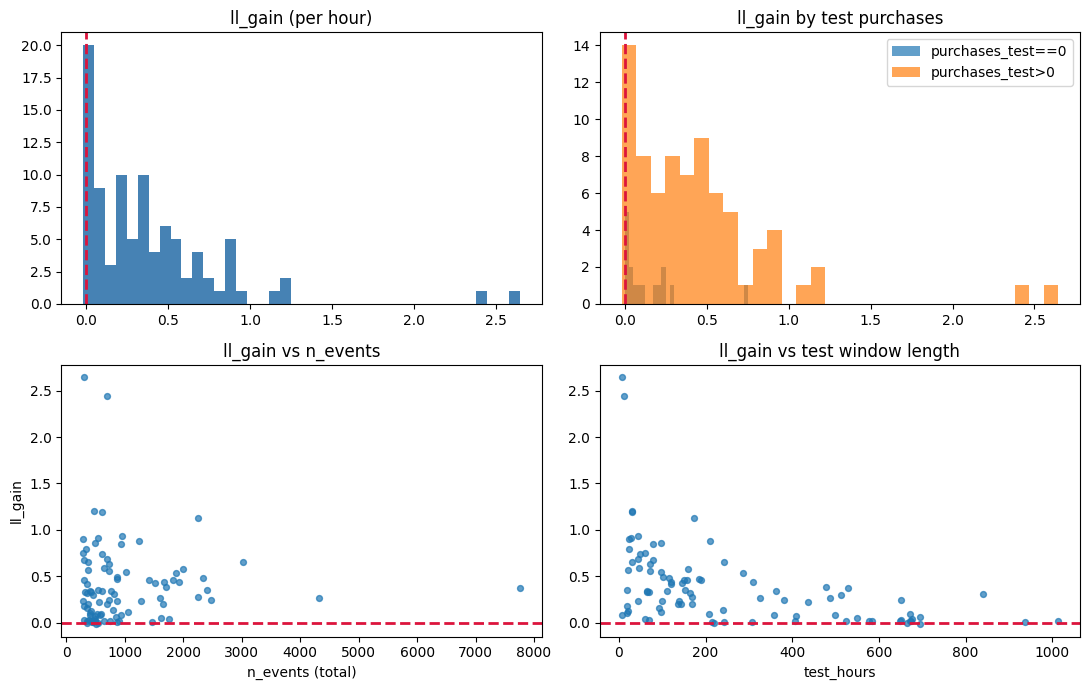

In [16]:
fig, ax = plt.subplots(2, 2, figsize=(11, 7))

# ll_gain histogram
ax[0, 0].hist(df.ll_gain, bins=40, color='steelblue')
ax[0, 0].axvline(0, color='crimson', linestyle='--', linewidth=2)
ax[0, 0].set_title('ll_gain (per hour)')

# ll_gain histogram by purchases_test==0
ax[0, 1].hist(df.loc[p0, 'll_gain'], bins=30, alpha=0.7, label='purchases_test==0')
ax[0, 1].hist(df.loc[~p0, 'll_gain'], bins=30, alpha=0.7, label='purchases_test>0')
ax[0, 1].axvline(0, color='crimson', linestyle='--', linewidth=2)
ax[0, 1].set_title('ll_gain by test purchases')
ax[0, 1].legend()

# scatter: ll_gain vs n_events
ax[1, 0].scatter(df.n_events, df.ll_gain, s=18, alpha=0.7)
ax[1, 0].axhline(0, color='crimson', linestyle='--', linewidth=2)
ax[1, 0].set_xlabel('n_events (total)')
ax[1, 0].set_ylabel('ll_gain')
ax[1, 0].set_title('ll_gain vs n_events')

# scatter: ll_gain vs test_hours
ax[1, 1].scatter(df.test_hours, df.ll_gain, s=18, alpha=0.7)
ax[1, 1].axhline(0, color='crimson', linestyle='--', linewidth=2)
ax[1, 1].set_xlabel('test_hours')
ax[1, 1].set_title('ll_gain vs test window length')

plt.tight_layout()


## Fitted alpha (by event type)
For the purchase-target model we keep 3 excitation parameters:
- `alpha_type_0` (view -> purchase)
- `alpha_type_1` (addtocart -> purchase)
- `alpha_type_2` (transaction -> purchase)


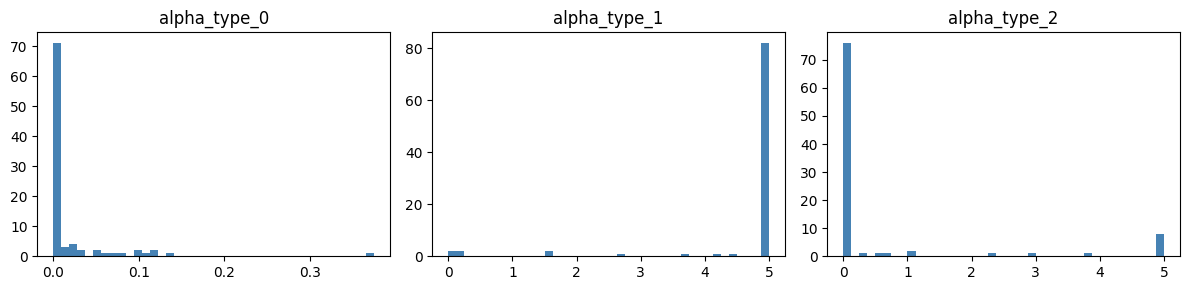

In [17]:
alpha_cols = ['alpha_type_0', 'alpha_type_1', 'alpha_type_2']
fig, ax = plt.subplots(1, 3, figsize=(12, 3))
for i, c in enumerate(alpha_cols):
    ax[i].hist(df[c].values, bins=40, color='steelblue')
    ax[i].set_title(c)
plt.tight_layout()


## Best / worst sequences

In [18]:
cols = ['seq_id', 'n_events', 'purchases_train', 'purchases_test', 'test_hours', 'll_gain']
print('Top 10 by ll_gain:')
display(df.sort_values('ll_gain', ascending=False)[cols].head(10))
print('Bottom 10 by ll_gain:')
display(df.sort_values('ll_gain', ascending=True)[cols].head(10))


Top 10 by ll_gain:


,seq_id,n_events,purchases_train,purchases_test,test_hours,ll_gain
27,438441,311,39,8,6.309296,2.644595
68,974226,694,39,6,12.005789,2.438586
28,475479,472,3,11,30.150026,1.198063
60,863219,603,13,15,29.802019,1.196161
43,684514,2246,106,83,173.181284,1.128476
10,198270,956,76,28,43.976837,0.928037
24,404403,539,34,11,28.896642,0.907506
35,547506,290,9,9,24.320828,0.899975
50,757355,1251,27,74,210.069125,0.878878
74,1075423,483,23,24,98.330511,0.853292


Bottom 10 by ll_gain:


,seq_id,n_events,purchases_train,purchases_test,test_hours,ll_gain
87,1313381,507,2,4,695.526779,-0.018617
84,1185234,347,6,0,219.958585,-0.000748
9,198153,536,9,1,665.209553,-0.000359
0,38015,861,2,0,307.903921,0.001522
33,524146,463,2,0,214.059733,0.004061
4,85734,1461,12,3,936.124127,0.008129
42,673572,443,7,0,242.199419,0.008308
91,1403769,469,6,1,649.555100,0.010996
55,825321,895,3,1,583.640773,0.011290
79,1134975,347,25,1,576.540441,0.014028
